In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "mohankrishnathalla/predict-customer-churn-submission-dataset"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'predict-customer-churn-submission-dataset' dataset.
Dataset path: /kaggle/input/predict-customer-churn-submission-dataset


In [ ]:
import os

files = os.listdir(path)
print(files)

['V18.csv', 'V4.csv', 'V1.csv', 'V9.csv', 'V7.csv', 'V17.csv', 'V12.csv', 'V3.csv', 'V11.csv', 'V15.csv', 'V6.csv', 'V5.csv', 'V10.csv', 'V2.csv', 'Original.csv', 'V16.csv', 'V8.csv', 'V14.csv', 'V19.csv', 'V13.csv']


In [ ]:
import pandas as pd

# Đọc file Origin.csv từ đường dẫn đã tải về
df = pd.read_csv(f"{path}/Original.csv")

# Xem kích thước dữ liệu
print("Shape:", df.shape)

# Xem vài dòng đầu tiên
print(df.head())


Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [ ]:
# Chuẩn hóa dữ liệu thành vector đặc trưng

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Loại bỏ cột không cần thiết
df = df.drop(columns=["customerID"])

# Chuyển đổi TotalCharges sang số và xử lý giá trị thiếu
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Mã hóa biến mục tiêu
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Mã hóa các biến nhị phân Yes/No (ngoại trừ gender)
binary_cols = ["Partner","Dependents","PhoneService",
               "OnlineSecurity","OnlineBackup","DeviceProtection",
               "TechSupport","StreamingTV","StreamingMovies","PaperlessBilling"]

for col in binary_cols:
    df[col] = df[col].map({"Yes":1,"No":0})

# Xử lý riêng cho gender (Male/Female)
df["gender"] = df["gender"].map({"Female":0, "Male":1})

# One-Hot Encoding cho các biến nhiều giá trị
multi_cat_cols = ["MultipleLines","InternetService","Contract","PaymentMethod"]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# Chuẩn hóa dữ liệu số
numeric_cols = ["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Tách vector đặc trưng X và biến mục tiêu y
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
X.head()


Shape X: (7043, 24)
Shape y: (7043,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-0.439916,1,0,-1.277445,0,0.0,1.0,0.0,0.0,...,-0.994242,True,False,False,False,False,False,False,True,False
1,1,-0.439916,0,0,0.066327,1,1.0,0.0,1.0,0.0,...,-0.173244,False,False,False,False,True,False,False,False,True
2,1,-0.439916,0,0,-1.236724,1,1.0,1.0,0.0,0.0,...,-0.959674,False,False,False,False,False,False,False,False,True
3,1,-0.439916,0,0,0.514251,0,1.0,0.0,1.0,1.0,...,-0.194766,True,False,False,False,True,False,False,False,False
4,0,-0.439916,0,0,-1.236724,1,0.0,0.0,0.0,0.0,...,-0.940470,False,False,True,False,False,False,False,True,False


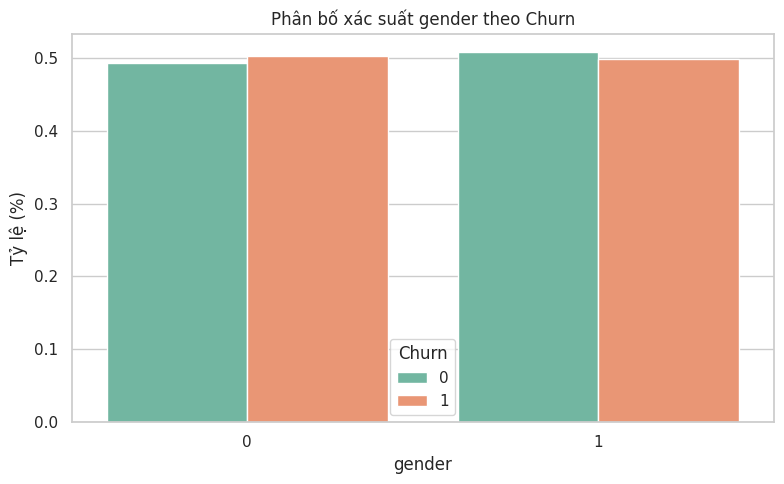

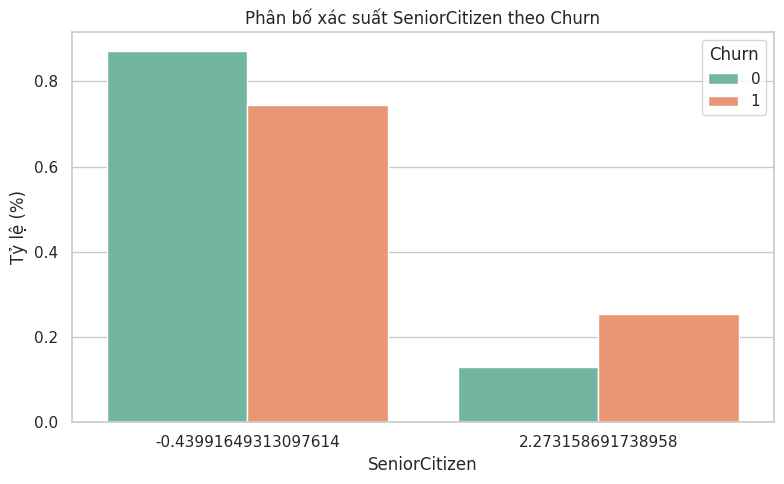

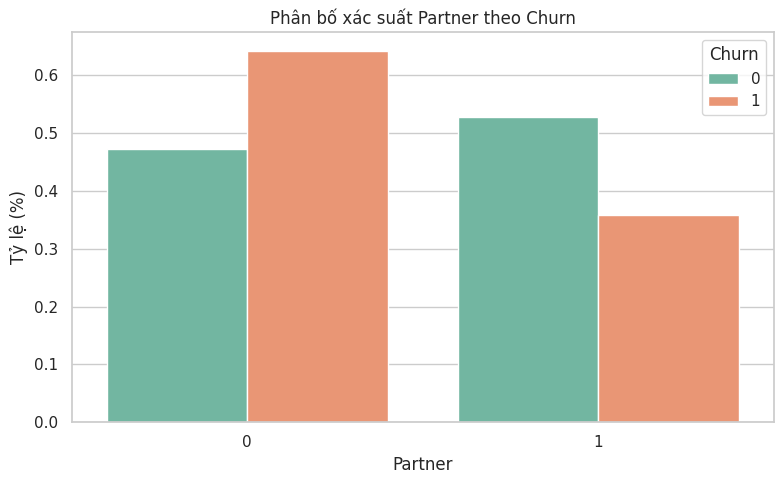

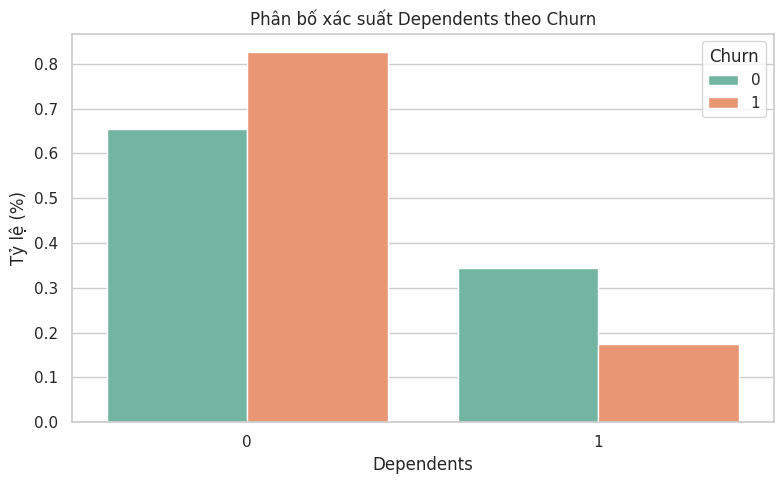

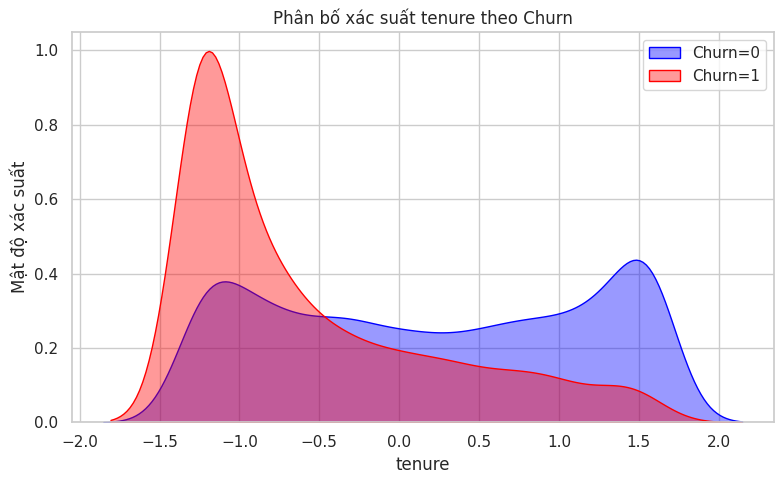

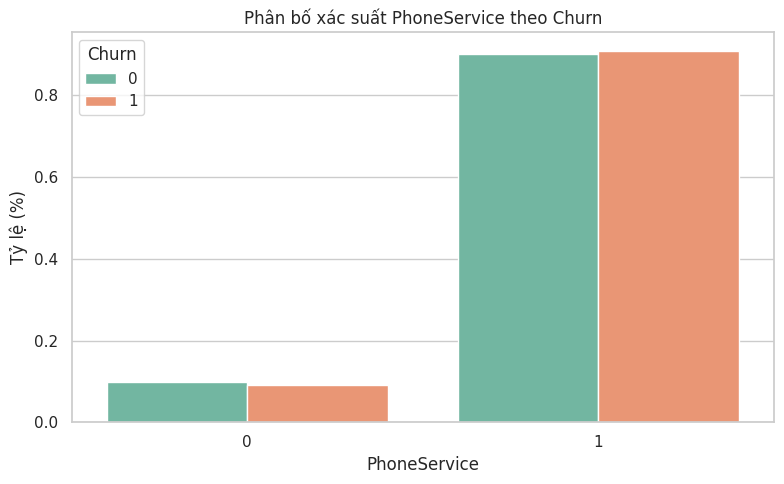

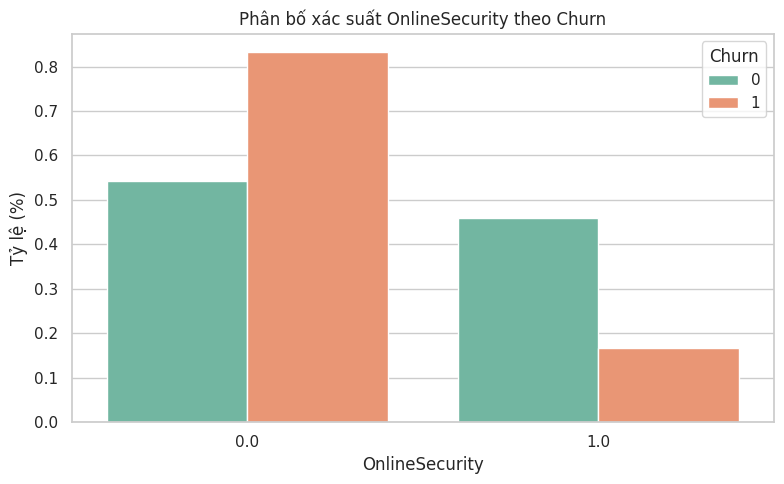

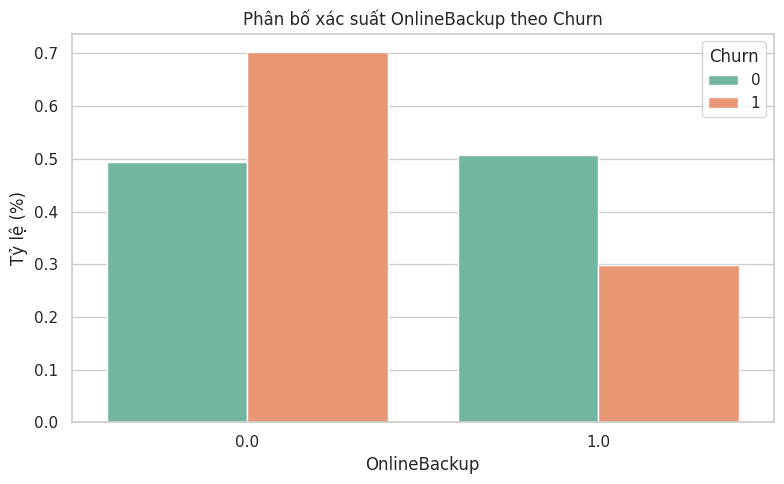

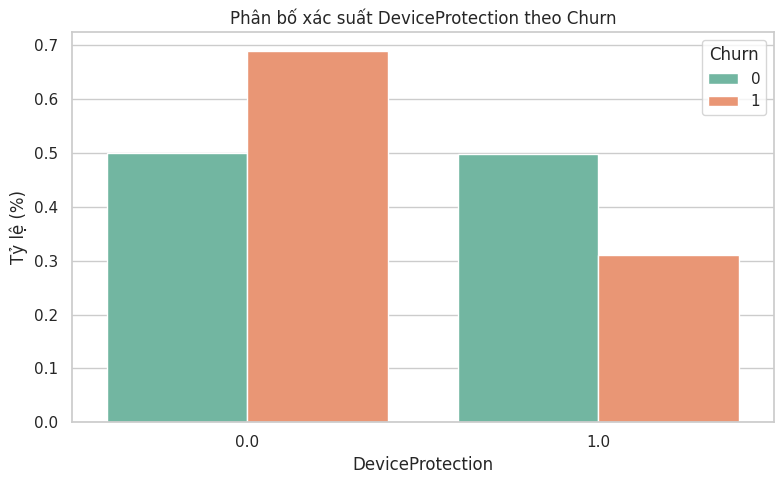

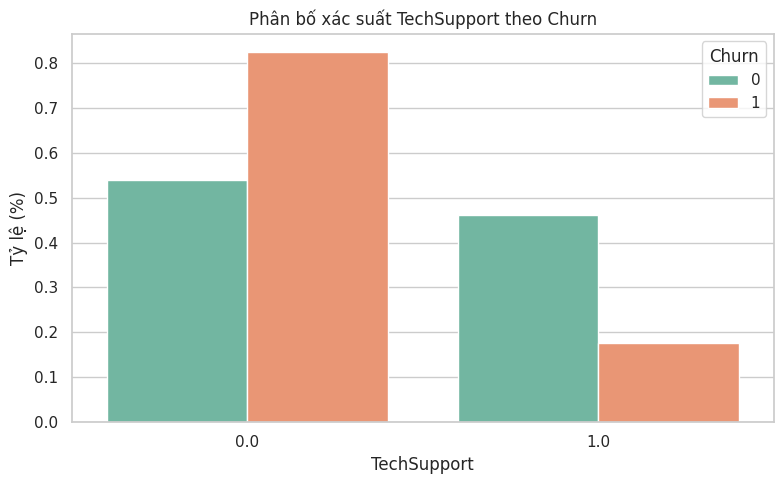

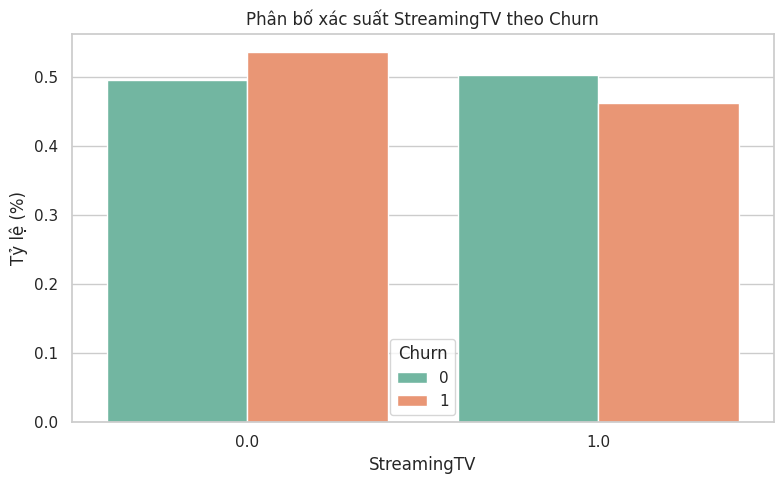

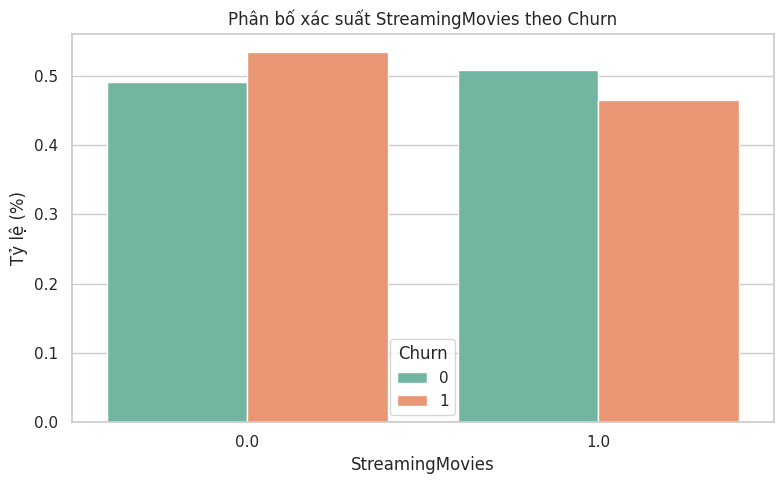

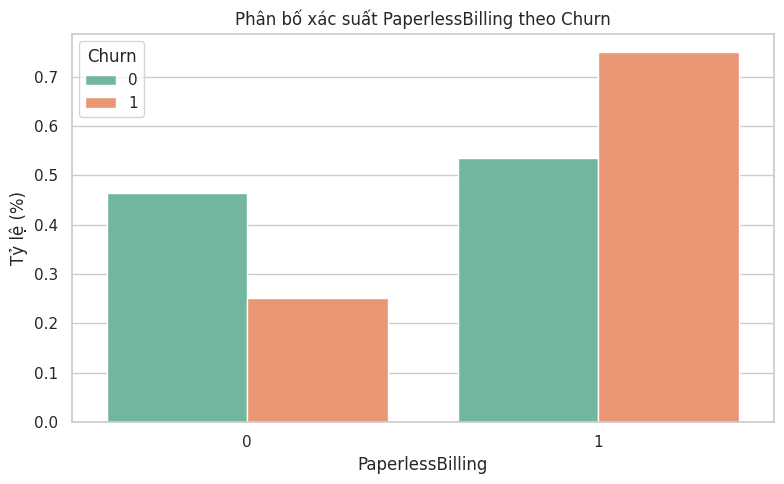

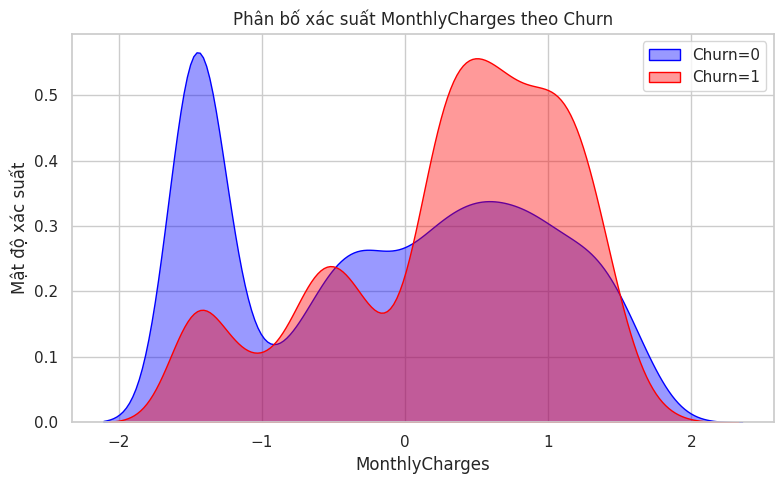

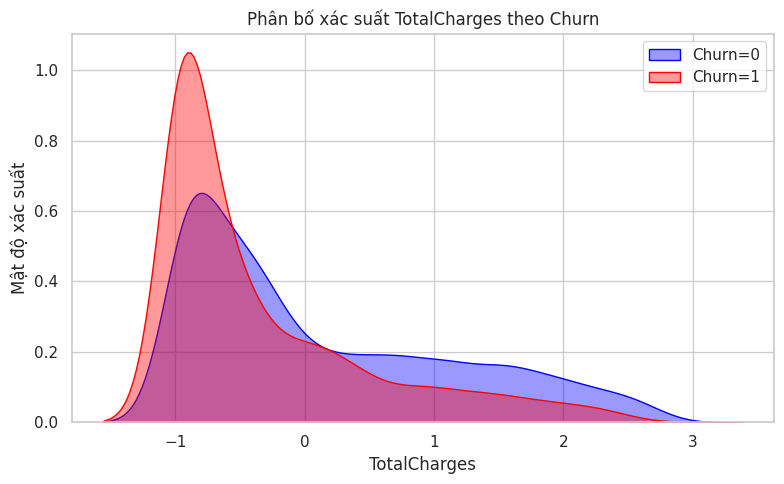

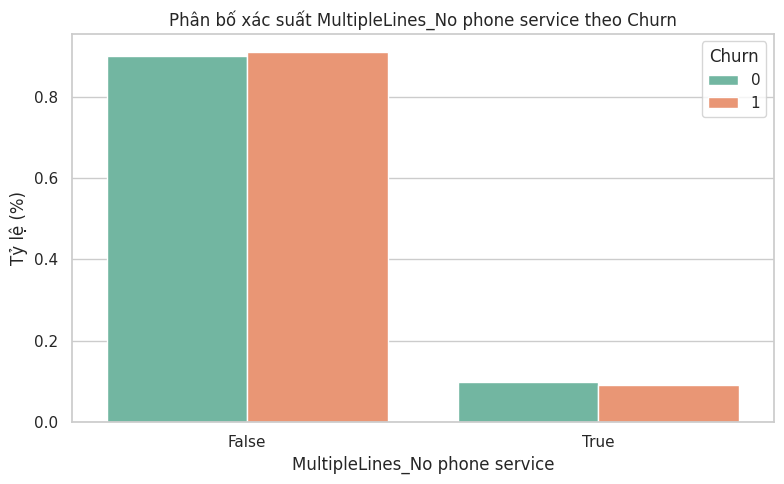

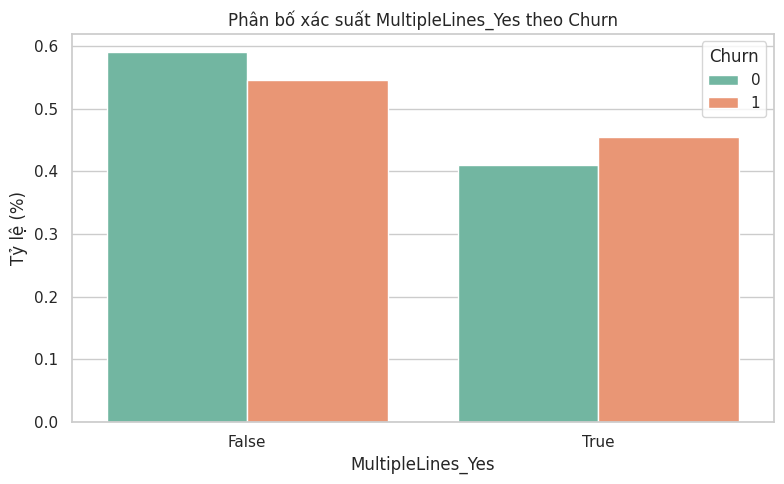

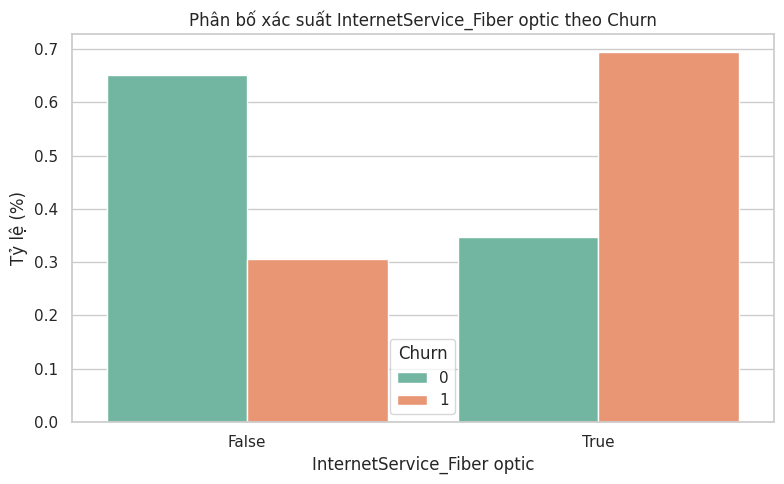

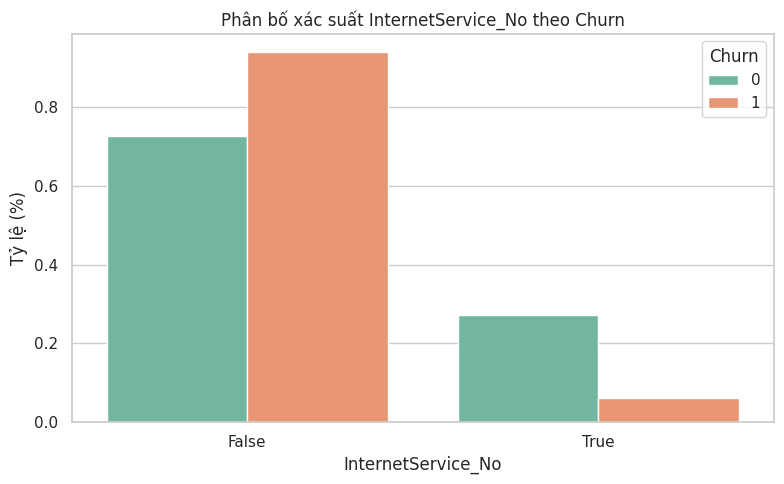

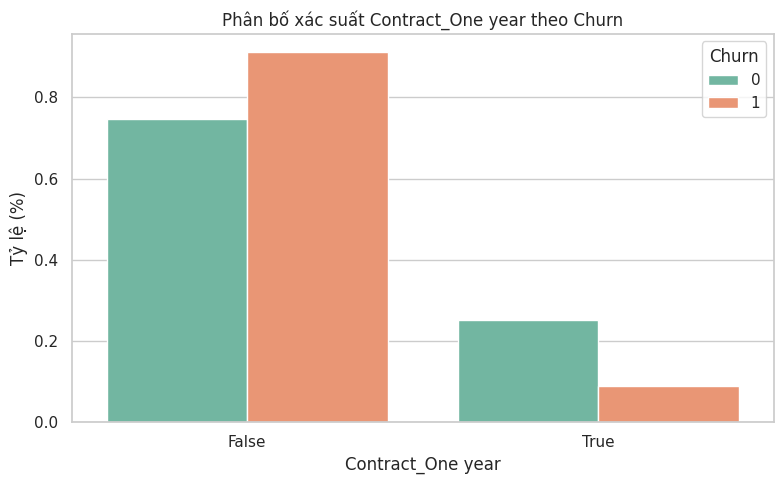

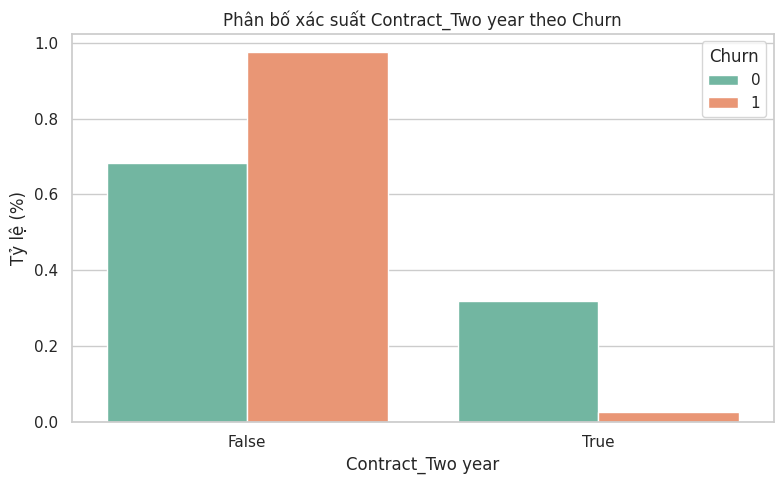

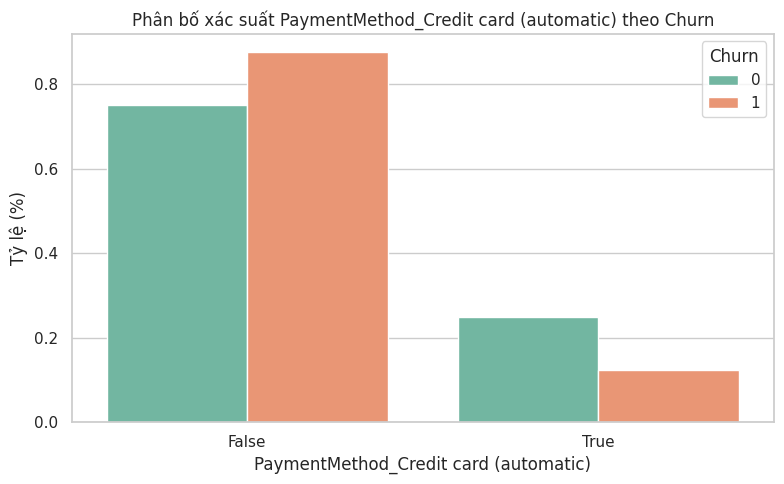

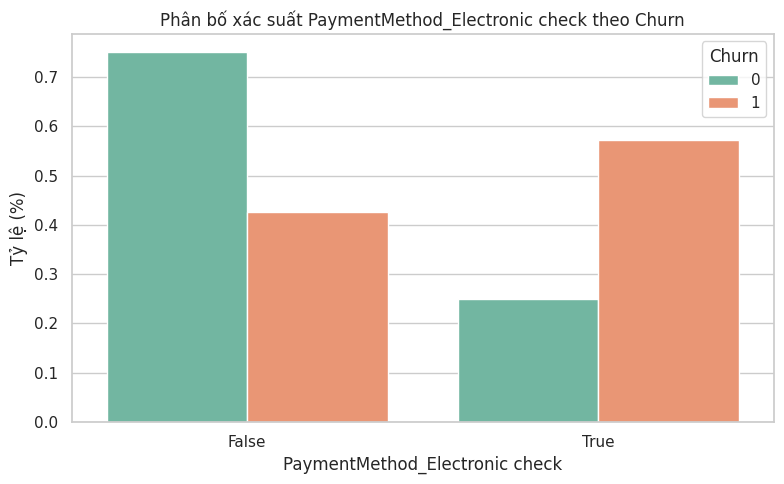

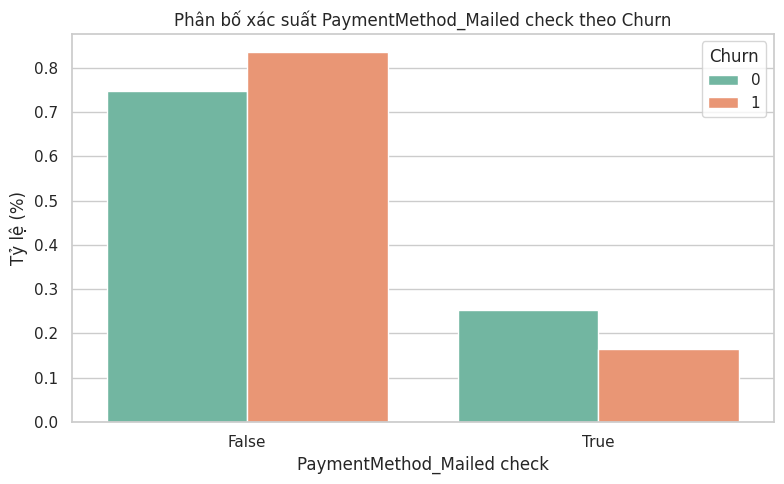

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Tách dữ liệu theo churn
df_churn0 = df[df["Churn"] == 0]
df_churn1 = df[df["Churn"] == 1]

# Lấy danh sách các cột đặc trưng (trừ cột mục tiêu)
feature_cols = [col for col in df.columns if col != "Churn"]

for col in feature_cols:
    plt.figure(figsize=(8,5))

    if df[col].nunique() <= 10:  # Biến phân loại
        # Tính tỷ lệ phần trăm cho từng nhóm churn
        prop0 = df_churn0[col].value_counts(normalize=True).reset_index()
        prop0.columns = [col, "proportion"]
        prop0["Churn"] = 0

        prop1 = df_churn1[col].value_counts(normalize=True).reset_index()
        prop1.columns = [col, "proportion"]
        prop1["Churn"] = 1

        prop_df = pd.concat([prop0, prop1])

        sns.barplot(x=col, y="proportion", hue="Churn", data=prop_df, palette="Set2")
        plt.ylabel("Tỷ lệ (%)")
    else:  # Biến số liên tục
        sns.kdeplot(data=df_churn0, x=col, fill=True, label="Churn=0", alpha=0.4, color="blue")
        sns.kdeplot(data=df_churn1, x=col, fill=True, label="Churn=1", alpha=0.4, color="red")
        plt.ylabel("Mật độ xác suất")
        plt.legend()

    plt.title(f"Phân bố xác suất {col} theo Churn")
    plt.tight_layout()
    plt.show()
